# Decision Tree Evaluation Example

In [31]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#When importing libraries that have several packages with corresponding functions
#If you know you will only need to use one specific function from a certain package
#It is better to simply import it directly, as seen below, since it is more efficient and allows for greater simplicity later on
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics

## Load Data

In [32]:
#Read in the data from the github repo, you should also have this saved locally...
bank_data = pd.read_csv("https://raw.githubusercontent.com/UVADS/DS-3001/main/07_ML_Eval_Metrics/bank.csv")

In [ ]:
#Let's take a look
print(bank_data.dtypes)
bank_data.head()

## Clean the Data

In [33]:
#Drop any rows that are incomplete (rows that have NA's in them)
bank_data = bank_data.dropna() #dropna drops any rows with any NA value by default

In [34]:
#In this example our target variable is the column 'signed up', lets convert it to a category so we can work with it
bank_data['signed up'] = bank_data['signed up'].astype("category")

In [5]:
bank_data.dtypes #looks good

age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
contact        object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
signed up    category
dtype: object

## Decision Tree data prep using Pipeline

In [35]:
#Drop job, contact, and poutcome since they are not useful for this example
bank_data = bank_data.drop(['job','contact','poutcome'], axis=1)

#Isolate the independent and dependent variables
X = bank_data.drop(['signed up'], axis=1) #Feature set
y = bank_data['signed up'] #target variable

In [37]:
#Identify numeric and categorical columns for the Pipeline's ColumnTransformer
numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns: ['marital', 'education', 'default', 'housing']


In [38]:
#Build a ColumnTransformer to handle preprocessing in a Pipeline
#This replaces the manual scaling and one-hot encoding done previously
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

In [39]:
#Create the Pipeline: preprocessing + Decision Tree classifier
#The Pipeline ensures that all preprocessing steps and the model are bundled together
#This avoids data leakage and makes the workflow reproducible
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=21))
])

## Train/Test Split

In [40]:
#Now we partition using train_test_split
#We split into training (70%) and test (30%) sets
#The test set is held out for final evaluation ONLY
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify=y, random_state=21)
#Remember specifying the parameter 'stratify' is essential to preserve class proportions when splitting, reducing sampling error
#Also set the random_state so our results can be reproducible

## Model Selection with Cross-Validation
Instead of manually creating a tuning set, we use cross-validation on the training data
to select the best hyperparameters for the Decision Tree.

In [11]:
#Define a grid of hyperparameters to search over
#These are key Decision Tree parameters that control model complexity
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

In [41]:
#Use GridSearchCV to perform 5-fold cross-validation over the parameter grid
#This searches for the best combination of hyperparameters using only the training data
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

#Fit the grid search on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,estimator,Pipeline(step...m_state=21))])
,param_grid,"{'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [42]:
#Let's see the best parameters found by cross-validation
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best cross-validation accuracy: 0.8926291171338805


In [43]:
#Let's also look at cross-validation scores for the best model
best_pipeline = grid_search.best_estimator_
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std() * 2))

Cross-validation scores: [0.89194499 0.89178127 0.89341847 0.89276359 0.89323727]
Mean CV accuracy: 0.8926 (+/- 0.0013)


## Final Evaluation on the Test Set
Now that we have selected the best model using cross-validation,
we evaluate it on the held-out test set for an unbiased performance estimate.

In [44]:
#This is how well our best model does when applied to the test set
print("Test set accuracy:", best_pipeline.score(X_test, y_test))

Test set accuracy: 0.8953319581327832


## Evaluation Metrics

In [16]:
#In order to take a look at other metrics, we first need to extract certain information from our model
#Let's retrieve the probabilities calculated from our test set
bank_prob1 = best_pipeline.predict_proba(X_test) #This function gives percent probability for both class (0,1)
bank_prob1[:5] #both are important depending on our question, in this example we want the positive class

array([[0.98151534, 0.01848466],
       [0.80582524, 0.19417476],
       [0.74887892, 0.25112108],
       [0.74887892, 0.25112108],
       [0.9980242 , 0.0019758 ]])

In [17]:
#Now let's retrieve the predictions, based on the test set...
bank_pred1 = best_pipeline.predict(X_test)
bank_pred1[:5] #looks good, notice how the probabilities above correlate with the predictions below

array([0, 0, 0, 0, 0])

In [18]:
#Building a dataframe for simplicity, including everything we extracted and the target
final_model = pd.DataFrame({'neg_prob':bank_prob1[:, 0], 'pred':bank_pred1, 'target':y_test, 'pos_prob':bank_prob1[:, 1]})
#Now everything is in one place!

In [19]:
final_model.head() #Nice work!

,neg_prob,pred,target,pos_prob
30264,0.981515,0,0,0.018485
21274,0.805825,0,0,0.194175
29205,0.748879,0,0,0.251121
23793,0.748879,0,0,0.251121
9776,0.998024,0,0,0.001976


In [20]:
#Now let's create a confusion matrix by inputing the predications from our model and the original target
metrics.confusion_matrix(final_model.target, final_model.pred) #looks good, but simplistic...

array([[11178,   389],
       [  981,   541]])

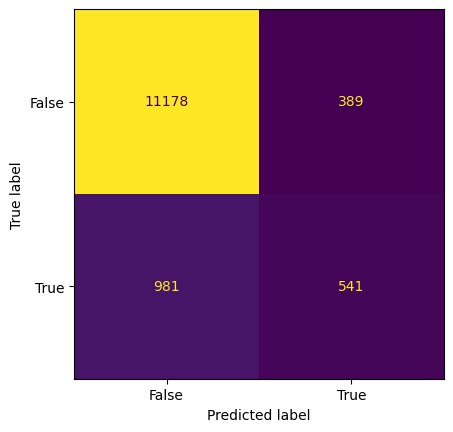

In [21]:
#Let's make it a little more visually appealing so we know what we are looking at
#This function allows us to include labels which will help us determine number of true positives, fp, tn, and fn
metrics.ConfusionMatrixDisplay.from_predictions(final_model.target, final_model.pred, display_labels=[False, True], colorbar=False)
#Ignore the color, as there is so much variance in this example it really is not telling us anything

In [22]:
#What if we want to adjust the threshold to produce a new set of evaluation metrics
#Let's build a function so we can make the threshold whatever we want, not just the default 50%
def adjust_thres(x, y, z):
    """
    x=pred_probabilities
    y=threshold
    z=tune_outcome
    """
    thres = pd.DataFrame({'new_preds': [1 if i > y else 0 for i in x]})
    thres.new_preds = thres.new_preds.astype('category')
    con_mat = metrics.confusion_matrix(z, thres)
    print(con_mat)

In [23]:
# Give it a try with a threshold of .40
adjust_thres(final_model.pos_prob, .40, final_model.target)

#What's the difference? Try different percents now, what happens?

[[11017   550]
 [  874   648]]


Text(0.5, 0, 'False Positive Rate')

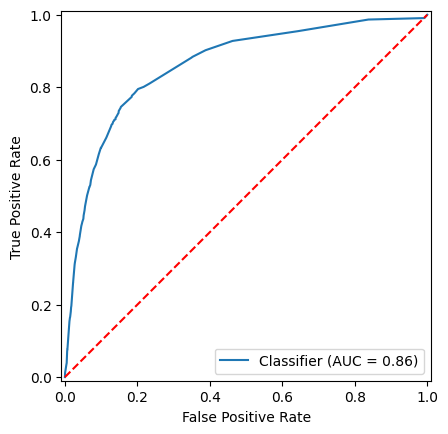

In [24]:
#Now let's use our model to obtain an ROC Curve and the AUC
metrics.RocCurveDisplay.from_predictions(final_model.target, final_model.pos_prob)
#Set labels and midline...
plt.plot([0, 1], [0, 1],'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

In [25]:
#Let's extract the specific AUC value now
metrics.roc_auc_score(final_model.target, final_model.pos_prob) #Looks good!

0.8596605993283489

In [26]:
#Determine the log loss
metrics.log_loss(final_model.target, final_model.pos_prob)

0.3052163688392359

In [27]:
#Get the F1 Score
metrics.f1_score(final_model.target, final_model.pred)
# what does this mean?

0.44127243066884175

In [28]:
#generate function to calculate the F1 manually (you can use precision and recall functions)
#This is a good way to understand how the F1 score is calculated
#Then run it on the is dataset and compare with above function

In [29]:
#Extra metrics
print(metrics.classification_report(final_model.target, final_model.pred)) #Nice Work!

              precision    recall  f1-score   support

           0       0.92      0.97      0.94     11567
           1       0.58      0.36      0.44      1522

    accuracy                           0.90     13089
   macro avg       0.75      0.66      0.69     13089
weighted avg       0.88      0.90      0.88     13089



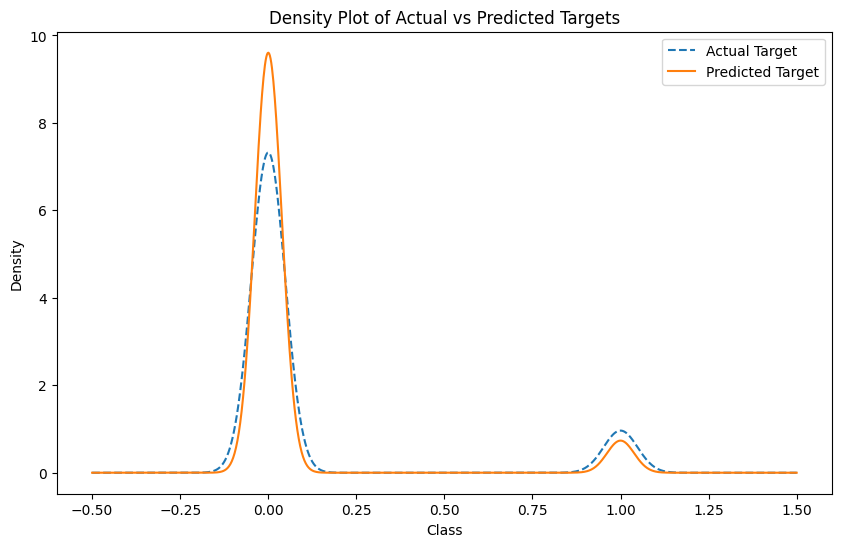

In [30]:
# Plot density plots of the final_model.target and final_model.pred on the same chart
plt.figure(figsize=(10, 6))
final_model['target'].astype(int).plot(kind='density', label='Actual Target', linestyle='--')
final_model['pred'].astype(int).plot(kind='density', label='Predicted Target', linestyle='-')
plt.title('Density Plot of Actual vs Predicted Targets')
plt.xlabel('Class')
plt.legend()
plt.show()

In [ ]:
# Calculate cross-entropy loss
cross_entropy_loss = metrics.log_loss(final_model.target, final_model.pos_prob)
print(f"Cross-Entropy Loss: {cross_entropy_loss}")

In [ ]:
# Calculate cross-entropy loss manually
def cross_entropy(y_true, y_pred):
    epsilon = 1e-15 # Small value to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon) # Clip the predicted values to avoid log(0), no 0s or 1s
    ce_loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return ce_loss

#manual_cross_entropy_loss = cross_entropy(final_model.target, final_model.pos_prob)
# run the above line but make final_model.target and final_model.pos_prob numpy arrays
# so that the function can run properly
manual_cross_entropy_loss = cross_entropy(final_model.target.to_numpy(), final_model.pos_prob)

print(f"Manual Cross-Entropy Loss: {manual_cross_entropy_loss}")

In [ ]:
print(f"Cross-Entropy Loss: {cross_entropy_loss}")

Cross-entropy and log loss are essentially the same concept and are
often used interchangeably in the context of classification evaluation.
Both terms refer to a measure of the difference between the predicted
probability distribution and the actual distribution of the target classes.

**Evaluate the cross-entropy loss**

Lower values of cross-entropy loss indicate better performance of the model.
The cross-entropy loss value should be compared with other models or baseline
values to determine if it is good. In general, a cross-entropy loss close to
0 indicates a good model, but the context and specific problem domain matter.
Over 1 is considered bad as well.

### Question
What else can cross-entropy loss be used for? Is there an application in Neural Networks?

**Bonus:** What is the softmax function and how is it related to cross-entropy loss?

## Nested Cross-Validation
Nested cross-validation provides an unbiased estimate of model performance
when hyperparameter tuning is involved. The outer loop estimates generalization
error, while the inner loop selects the best hyperparameters for each fold.
This avoids the optimistic bias that can occur when using a single train/test
split with cross-validated hyperparameter tuning.

In [ ]:
from sklearn.model_selection import KFold

#Define inner and outer cross-validation strategies
inner_cv = KFold(n_splits=5, shuffle=True, random_state=21)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

#Build a fresh pipeline for nested CV (same structure as before)
nested_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=21))
])

#The inner loop: GridSearchCV handles hyperparameter tuning within each outer fold
nested_grid_search = GridSearchCV(
    nested_pipeline,
    param_grid,
    cv=inner_cv,
    scoring='accuracy',
    n_jobs=-1
)

#The outer loop: cross_val_score estimates generalization performance
#Each outer fold trains a full GridSearchCV (inner loop) on the training portion
nested_scores = cross_val_score(nested_grid_search, X, y, cv=outer_cv, scoring='accuracy')

In [ ]:
print("Nested CV scores:", nested_scores)
print("Mean nested CV accuracy: {:.4f} (+/- {:.4f})".format(nested_scores.mean(), nested_scores.std() * 2))

In [ ]:
#Compare with the non-nested CV score to see the optimism bias
print("Non-nested CV accuracy (from GridSearchCV): {:.4f}".format(grid_search.best_score_))
print("Nested CV accuracy: {:.4f}".format(nested_scores.mean()))
print("Difference (optimism bias): {:.4f}".format(grid_search.best_score_ - nested_scores.mean()))
#A large difference suggests the non-nested estimate is overly optimistic

## Calibration
Calibration measures how well the predicted probabilities match actual outcomes.
A well-calibrated model means that when it predicts 70% probability, the event
should occur roughly 70% of the time. Decision trees can produce poorly calibrated
probabilities, so calibration analysis and correction are important.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

#Plot a calibration curve (reliability diagram) for the best model
#This shows predicted probability vs actual frequency of the positive class
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(best_pipeline, X_test, y_test, n_bins=10, ax=ax, name="Decision Tree")
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

In [ ]:
#Use CalibratedClassifierCV to improve calibration using Platt scaling (sigmoid)
#This wraps the pipeline and applies a post-hoc calibration step using cross-validation
calibrated_pipeline = CalibratedClassifierCV(best_pipeline, method='sigmoid', cv=5)
calibrated_pipeline.fit(X_train, y_train)

In [ ]:
#Compare calibrated vs uncalibrated predictions on the test set
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_estimator(best_pipeline, X_test, y_test, n_bins=10, ax=ax, name="Uncalibrated")
CalibrationDisplay.from_estimator(calibrated_pipeline, X_test, y_test, n_bins=10, ax=ax, name="Calibrated (Sigmoid)")
plt.title("Calibration Comparison: Uncalibrated vs Calibrated")
plt.show()

In [ ]:
#Compare log loss before and after calibration
#Lower log loss indicates better calibrated probabilities
uncalibrated_probs = best_pipeline.predict_proba(X_test)[:, 1]
calibrated_probs = calibrated_pipeline.predict_proba(X_test)[:, 1]

print("Uncalibrated Log Loss: {:.4f}".format(metrics.log_loss(y_test, uncalibrated_probs)))
print("Calibrated Log Loss:   {:.4f}".format(metrics.log_loss(y_test, calibrated_probs)))

In [ ]:
#Compare Brier score (another calibration metric, lower is better)
from sklearn.metrics import brier_score_loss
print("Uncalibrated Brier Score: {:.4f}".format(brier_score_loss(y_test, uncalibrated_probs)))
print("Calibrated Brier Score:   {:.4f}".format(brier_score_loss(y_test, calibrated_probs)))